In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv('https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [5]:
scaler = StandardScaler()

X_scale = scaler.fit_transform(X)

In [7]:
wcss = []

model = KMeans(n_clusters=5,random_state=42)

model.fit(X_scale)

print(model.inertia_)

65.56840815571681


C:\Users\bhosa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [8]:
wcss = []

for i in range(1,11):
    
    model = KMeans(n_clusters=i,random_state=42)
    
    model.fit(X_scale)
    
    wcss.append(model.inertia_)

C:\Users\bhosa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bhosa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bhosa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\bhosa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [11]:
wcss

[400.00000000000006,
 273.66888662642015,
 157.7040081503594,
 109.22822707921344,
 65.56840815571681,
 60.13287487193421,
 49.668244837367986,
 37.31912287833883,
 32.49508119910091,
 30.0593226940422]

[]

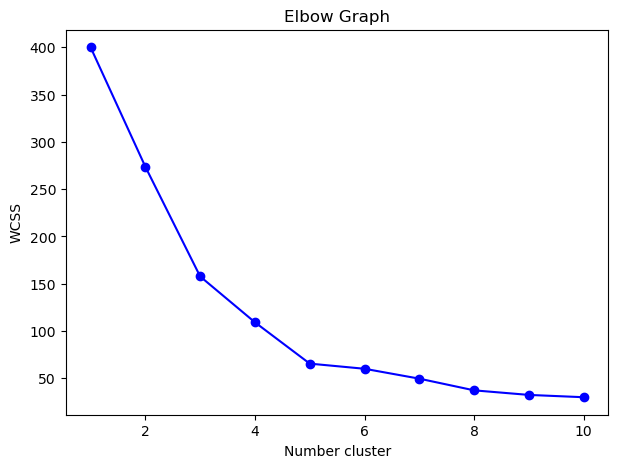

In [12]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss,'bo-')
plt.xlabel('Number cluster')
plt.ylabel('WCSS')
plt.title('Elbow Graph')
plt.plot()

In [13]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scale)

C:\Users\bhosa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


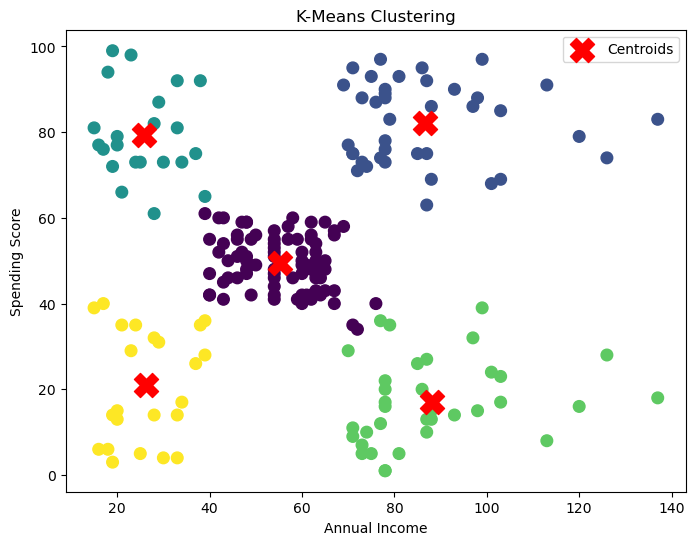

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=labels,
    cmap='viridis',
    s=70
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker='X',
    s=300,
    c='red',
    label='Centroids'
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("K-Means Clustering")

plt.legend()

plt.show()